<a href="https://colab.research.google.com/github/HeyManan/Road-Sign-Recognition/blob/main/Hardware_Accelerators_Project_Group_11(CPU).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam,lr_scheduler
import random
from torch.utils.data import DataLoader, random_split
from torchsummary import summary
import matplotlib.pyplot as plt

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
seed = 42
torch.manual_seed(seed)
random.seed(seed)

train_transform = transforms.Compose([
    transforms.Lambda(lambda img: img.convert("RGB")),
    transforms.RandomRotation(5),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.RandomResizedCrop(32, scale=(0.9, 1.1)),
    transforms.Resize((32, 32)),
    transforms.ToTensor()
])

val_transform = transforms.Compose([
    transforms.Lambda(lambda img: img.convert("RGB")),
    transforms.Resize((32, 32)),
    transforms.ToTensor()
])

full_dataset = torchvision.datasets.GTSRB(
    root='./data', split='train', download=True, transform=None)

split_ratio = 0.2
dataset_size = len(full_dataset)
val_size = int(split_ratio * dataset_size)
train_size = dataset_size - val_size

train_data, val_data = random_split(full_dataset, [train_size, val_size])

train_data.dataset.transform = train_transform
val_data.dataset.transform = val_transform


batch_size = 32

trainloader = DataLoader(train_data, batch_size=batch_size,
                         shuffle=True, num_workers=2)
valloader = DataLoader(val_data, batch_size=batch_size,
                       shuffle=False, num_workers=2)


testset = torchvision.datasets.GTSRB(
    root='./data', split='test', download=True, transform=val_transform)

testloader = DataLoader(testset, batch_size=batch_size,
                        shuffle=False, num_workers=2)

100%|██████████| 187M/187M [00:10<00:00, 17.2MB/s]
100%|██████████| 89.0M/89.0M [00:05<00:00, 17.3MB/s]
100%|██████████| 99.6k/99.6k [00:00<00:00, 220kB/s]


In [ ]:
class Net(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(Net, self).__init__()
        self.input_dim = input_dim
        self.output_dim = output_dim

        self.flatten = nn.Flatten()

        self.l2_lambda = 0.001  # Typical L2 regularization value

        self.gpu_conv1 = nn.Conv2d(in_channels=3, out_channels=64, kernel_size=3, padding='same')
        self.gpu_conv2 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding='same')
        self.gpu_maxpool1 = nn.MaxPool2d(2)
        self.gpu_batchnorm1 = nn.BatchNorm2d(128)
        self.gpu_dropout1 = nn.Dropout(0.25)

        self.gpu_conv3 = nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding='same')
        self.gpu_conv4 = nn.Conv2d(in_channels=256, out_channels=512, kernel_size=3, padding='same')
        self.gpu_maxpool2 = nn.MaxPool2d(2)
        self.gpu_batchnorm2 = nn.BatchNorm2d(512)
        self.gpu_dropout2 = nn.Dropout(0.25)

        self.gpu_dense1 = nn.Linear(32768, 512)
        self.gpu_dense2 = nn.Linear(512, 128)
        self.gpu_dropout3 = nn.Dropout(0.2)
        self.gpu_dense3 = nn.Linear(128, output_dim)

        self.cpu_conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.cpu_maxpool1 = nn.MaxPool2d(2)
        self.cpu_conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.cpu_maxpool2 = nn.MaxPool2d(2)
        self.cpu_conv3 = nn.Conv2d(64, 64, kernel_size=3, padding=1)

        height, width = 32, 32
        flattened_size = 64 * (height // 4) * (width // 4)  # 64 * 8 * 8 = 4096

        self.cpu_dense1 = nn.Linear(flattened_size, 64)
        self.cpu_dropout = nn.Dropout(0.5)
        self.cpu_dense2 = nn.Linear(64, output_dim)

        self.relu = nn.ReLU()
        self.softmax = nn.Softmax(dim=1)

    def forward(self, input: torch.Tensor) -> torch.Tensor:
        if input.device.type == 'cuda':

            x = self.relu(self.gpu_conv1(input))
            x = self.relu(self.gpu_conv2(x))
            x = self.gpu_maxpool1(x)
            x = self.gpu_batchnorm1(x)
            x = self.gpu_dropout1(x)

            x = self.relu(self.gpu_conv3(x))
            x = self.relu(self.gpu_conv4(x))
            x = self.gpu_maxpool2(x)
            x = self.gpu_batchnorm2(x)
            x = self.gpu_dropout2(x)

            x = self.flatten(x)
            x = self.relu(self.gpu_dense1(x))
            x = self.relu(self.gpu_dense2(x))
            x = self.gpu_dropout3(x)
            x = self.gpu_dense3(x)
            output = x
        else:
            x = self.relu(self.cpu_conv1(input))
            x = self.cpu_maxpool1(x)
            x = self.relu(self.cpu_conv2(x))
            x = self.cpu_maxpool2(x)
            x = self.relu(self.cpu_conv3(x))

            x = self.flatten(x)
            x = self.relu(self.cpu_dense1(x))
            x = self.cpu_dropout(x)
            x = self.cpu_dense2(x)
            output = x

        return output

In [ ]:
INPUT_DIM = 3*32*32
OUTPUT_DIM = 43
net = Net(INPUT_DIM, OUTPUT_DIM).to(device)

In [ ]:
def print_model_summary(model, input_size=(3, 32, 32)):
    print("Model Summary:")
    summary(model, input_size=input_size)

print_model_summary(net)

Model Summary:
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 32, 32]             896
              ReLU-2           [-1, 32, 32, 32]               0
         MaxPool2d-3           [-1, 32, 16, 16]               0
            Conv2d-4           [-1, 64, 16, 16]          18,496
              ReLU-5           [-1, 64, 16, 16]               0
         MaxPool2d-6             [-1, 64, 8, 8]               0
            Conv2d-7             [-1, 64, 8, 8]          36,928
              ReLU-8             [-1, 64, 8, 8]               0
           Flatten-9                 [-1, 4096]               0
           Linear-10                   [-1, 64]         262,208
             ReLU-11                   [-1, 64]               0
          Dropout-12                   [-1, 64]               0
           Linear-13                   [-1, 43]           2,795
Total params: 321,323
Tr

In [ ]:
def plot_metrics(train_accuracies, val_accuracies, train_losses, val_losses):
    epochs = range(1, len(train_accuracies) + 1)

    plt.figure(figsize=(12, 5))

    # Plot accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, [acc/100 for acc in train_accuracies], 'b-', label='train')
    plt.plot(epochs, [acc/100 for acc in val_accuracies], 'orange', label='val')
    plt.title('Model accuracy')
    plt.ylabel('accuracy')
    plt.xlabel('epochs')
    plt.legend()
    plt.ylim(0, 1.0)

    # Plot loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_losses, 'b-', label='train')
    plt.plot(epochs, val_losses, 'orange', label='val')
    plt.title('Model loss')
    plt.ylabel('loss')
    plt.xlabel('epochs')
    plt.legend()

    plt.tight_layout()
    plt.savefig('training_metrics.png')
    plt.show()

def train(model: nn.Module, trainloader: DataLoader, valloader: DataLoader, EPOCHS, LEARNING_RATE):
    optimizer = Adam(params=model.parameters(), lr=LEARNING_RATE)
    lr_s = lr_scheduler.LinearLR(optimizer, start_factor=1.0, end_factor=0.5, total_iters=10)
    criterion = nn.CrossEntropyLoss()

    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    for epoch in range(EPOCHS):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for i, data in enumerate(trainloader, 0):
            inputs, labels = data
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        avg_train_loss = running_loss / len(trainloader)
        train_accuracy = 100 * correct / total

        model.eval()
        val_running_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for data in valloader:
                inputs, labels = data
                inputs = inputs.to(device)
                labels = labels.to(device)

                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_running_loss += loss.item()

                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        avg_val_loss = val_running_loss / len(valloader)
        val_accuracy = 100 * val_correct / val_total

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        train_accuracies.append(train_accuracy)
        val_accuracies.append(val_accuracy)

        print(f"[Epoch {epoch+1}] Training Loss: {avg_train_loss:.4f}, Training Accuracy: {train_accuracy:.2f}%, "
              f"Validation Loss: {avg_val_loss:.4f}, Validation Accuracy: {val_accuracy:.2f}%")

        lr_s.step()

    print('Finished Training')

    plot_metrics(train_accuracies, val_accuracies, train_losses, val_losses)

    return train_accuracies, val_accuracies, train_losses, val_losses


def test(model: nn.Module, dataloader: DataLoader, max_samples=None) -> float:
    correct = 0
    total = 0
    n_inferences = 0

    with torch.no_grad():
        for data in dataloader:
            images, labels = data

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            other, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            if max_samples:
                n_inferences += images.shape[0]
                if n_inferences > max_samples:
                    break

    return 100 * correct / total

[Epoch 1] Training Loss: 2.8083, Training Accuracy: 21.05%, Validation Loss: 1.8234, Validation Accuracy: 40.48%
[Epoch 2] Training Loss: 1.9307, Training Accuracy: 37.09%, Validation Loss: 1.4400, Validation Accuracy: 50.68%
[Epoch 3] Training Loss: 1.6386, Training Accuracy: 44.59%, Validation Loss: 1.0960, Validation Accuracy: 62.91%
[Epoch 4] Training Loss: 1.3897, Training Accuracy: 51.83%, Validation Loss: 0.8039, Validation Accuracy: 75.66%
[Epoch 5] Training Loss: 1.2010, Training Accuracy: 57.70%, Validation Loss: 0.5966, Validation Accuracy: 81.51%
[Epoch 6] Training Loss: 1.0665, Training Accuracy: 62.04%, Validation Loss: 0.4262, Validation Accuracy: 87.73%
[Epoch 7] Training Loss: 0.9727, Training Accuracy: 65.03%, Validation Loss: 0.3669, Validation Accuracy: 89.96%
[Epoch 8] Training Loss: 0.9048, Training Accuracy: 67.31%, Validation Loss: 0.3167, Validation Accuracy: 91.85%
[Epoch 9] Training Loss: 0.8547, Training Accuracy: 69.10%, Validation Loss: 0.2667, Validation 

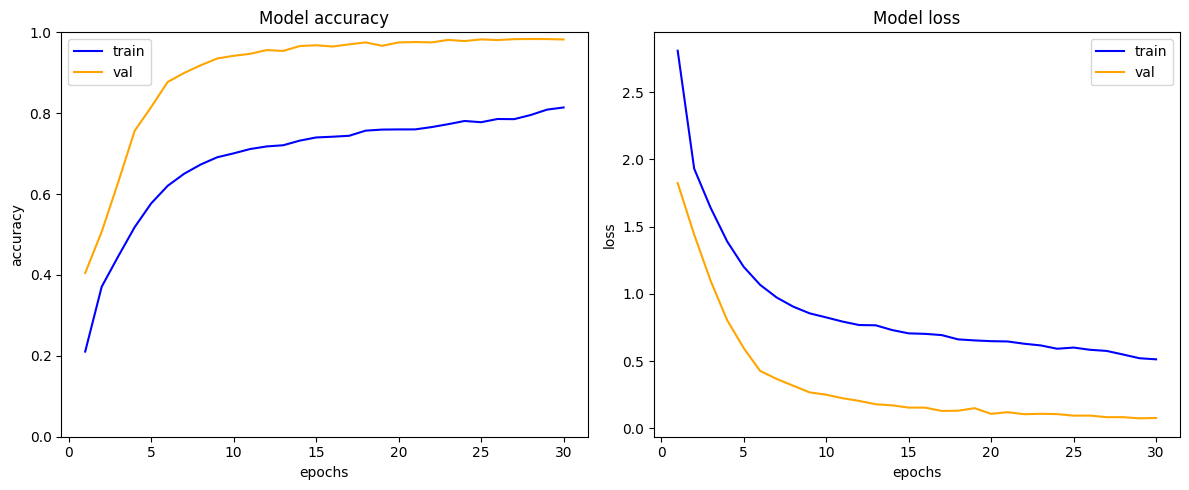

([21.053866366366368,
  37.09177927927928,
  44.585210210210214,
  51.834647147147145,
  57.699887387387385,
  62.04485735735736,
  65.03378378378379,
  67.309496996997,
  69.10191441441441,
  70.0731981981982,
  71.14301801801801,
  71.78584834834835,
  72.07207207207207,
  73.21227477477477,
  74.00525525525525,
  74.18825075075075,
  74.41816816816817,
  75.68975225225225,
  75.95251501501501,
  75.99005255255256,
  75.99943693693693,
  76.5671921921922,
  77.2850975975976,
  78.07807807807808,
  77.77308558558559,
  78.57075825825825,
  78.52852852852853,
  79.54673423423424,
  80.8887012012012,
  81.41891891891892],
 [40.484234234234236,
  50.67567567567568,
  62.912912912912915,
  75.65690690690691,
  81.51276276276276,
  87.72522522522523,
  89.95870870870871,
  91.85435435435436,
  93.52477477477477,
  94.20045045045045,
  94.68843843843844,
  95.60810810810811,
  95.40165165165165,
  96.60285285285285,
  96.80930930930931,
  96.49024024024024,
  97.03453453453453,
  97.5037537

In [ ]:
EPOCHS = 30
LEARNING_RATE = 0.0008
train(net, trainloader, valloader, EPOCHS, LEARNING_RATE)

In [ ]:
score = test(net, testloader)
print('Accuracy of the network on the test images: {}%'.format(score))

Accuracy of the network on the test images: 89.03404592240696%
